In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import userdata

folderPath = userdata.get("reinforcementLearningFolderPath")

In [3]:

roms_path = f"{folderPath}/Project/roms"

!mkdir -p roms
!cp -r "$roms_path" ./

In [4]:

# !sudo apt-get update
# !sudo apt-get install python3 python3-pip git zlib1g-dev libopenmpi-dev ffmpeg

In [5]:
!pip install stable-retro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 55.0 MB/s eta 0:00:00


In [6]:
!python -m retro.import ./roms

Importing SuperMarioWorld-Snes-v0
Imported 1 games


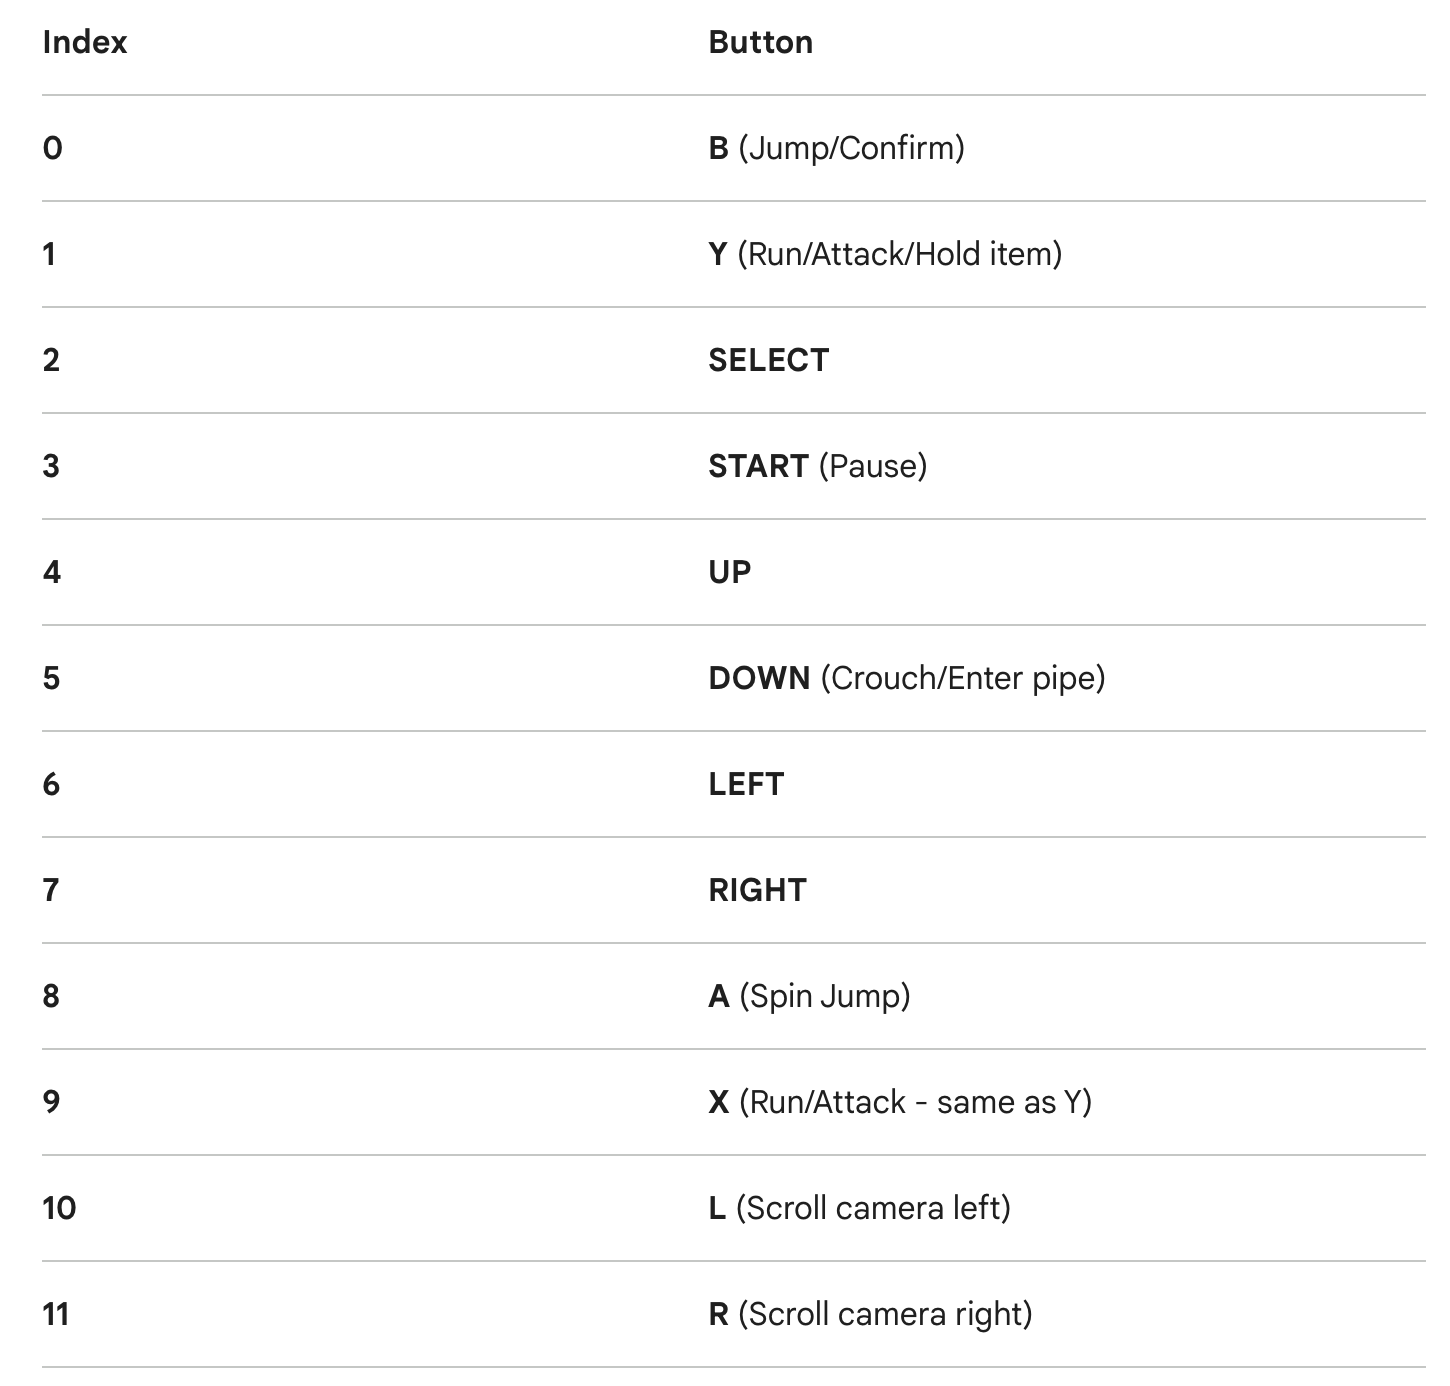

# Initial Testing

In [ ]:
import stable_retro as retro  # Keeps your code working with minimal changes

from gymnasium.wrappers import RecordVideo

import time

def main():
    # Create the environment
    # 'SuperMarioWorld-Snes' is the internal name used by retro
    env = retro.make(game='SuperMarioWorld-Snes-v0', state="DonutPlains1", render_mode="rgb_array", )
    steps = 0
    try:
        env = RecordVideo(env, video_folder="./", name_prefix="mario_initial_test",episode_trigger=lambda x: True)
        obs = env.reset()
        done = False

        print("Environment initialized. Running random actions...")

        while not done:
            # Render the game window
            env.render()

            # Pick a random action from the controller's button set
            action = env.action_space.sample()
            print(f"Action: {action}")
            action = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0] # Just Walk Right

            # Apply the action
            obs, reward, terminated, truncated, info = env.step(action)
            print(f"Observation: {obs}")
            print(f"Reward: {reward}")
            print(f"Terminated: {terminated}")
            print(f"Truncated: {truncated}")
            print(f"Info: {info}")

            # Check if the level is over or Mario died
            steps += 1
            done = terminated or truncated or steps > 500
            # time.sleep(1)

    # Close the environment
    finally:
        env.close()

if __name__ == "__main__":
    main()

In [ ]:
import json

path = '/usr/local/lib/python3.12/dist-packages/stable_retro/data/stable/SuperMarioWorld-Snes-v0/data.json'

new_data = {
  "info": {
    "coins":        {"address": 8261055, "type": "|u1"},
    "lives":        {"address": 8261054, "type": "|i1"},
    "score":        {"address": 8261428, "type": "<u4"},
    "x":            {"address": 0x94, "type": "<u2"},  # Mario X position (16-bit)
    "y":            {"address": 0x96, "type": "<u2"},  # Mario Y position (16-bit)
    "room_id":      {"address": 8257614, "type": "|u1"},  # Current room/level ID
    "powerup":      {"address": 8257622, "type": "|u1"},  # 0=small, 1=big, 2=cape, 3=fire
    "on_ground":    {"address": 8257570, "type": "|u1"},  # 1 if Mario is on ground
    "has_yoshi":    {"address": 8257642, "type": "|u1"},  # 1 if riding Yoshi
    "goal_reached": {"address": 8261002, "type": "|u1"},  # >0 when exit reached
  }
}

with open(path, 'w') as f:
    json.dump(new_data, f, indent=2)

print("✓ data.json updated")

In [ ]:
import stable_retro as retro  # Keeps your code working with minimal changes

from gymnasium.wrappers import RecordVideo

import time

def main():
    # Create the environment
    # 'SuperMarioWorld-Snes' is the internal name used by retro
    env = retro.make(game='SuperMarioWorld-Snes-v0', state="DonutPlains1", render_mode="rgb_array", )
    steps = 0
    try:
        env = RecordVideo(env, video_folder="./", name_prefix="mario_extended_info",episode_trigger=lambda x: True)
        obs = env.reset()
        done = False

        print("Environment initialized. Running random actions...")

        while not done:
            # Render the game window
            env.render()

            # Pick a random action from the controller's button set
            action = env.action_space.sample()
            # print(f"Action: {action}")
            action = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0] # Just Walk Right

            # Apply the action
            obs, reward, terminated, truncated, info = env.step(action)
            # print(f"Observation: {obs}")
            # print(f"Reward: {reward}")
            # print(f"Terminated: {terminated}")
            # print(f"Truncated: {truncated}")
            print(f"Info: {info}")

            # Check if the level is over or Mario died
            steps += 1
            done = terminated or truncated or steps > 1500
            if done:
                print(f"Terminated: {terminated}")
                print(f"Truncated: {truncated}")
            # time.sleep(1)

    # Close the environment
    finally:
        env.close()

if __name__ == "__main__":
    main()

In [ ]:
import json

path = '/usr/local/lib/python3.12/dist-packages/stable_retro/data/stable/SuperMarioWorld-Snes-v0/data.json'

new_data = {
  "info": {
    "coins":        {"address": 8261055, "type": "|u1"},
    "lives":        {"address": 8261054, "type": "|i1"},
    "score":        {"address": 8261428, "type": "<u4"},
    "x":            {"address": 0x94, "type": "<u2"},  # Mario X position (16-bit)
    "y":            {"address": 0x96, "type": "<u2"},  # Mario Y position (16-bit)
    "room_id":      {"address": 8257614, "type": "|u1"},  # Current room/level ID
    "powerup":      {"address": 8257622, "type": "|u1"},  # 0=small, 1=big, 2=cape, 3=fire
    "on_ground":    {"address": 8257570, "type": "|u1"},  # 1 if Mario is on ground
    "has_yoshi":    {"address": 8257642, "type": "|u1"},  # 1 if riding Yoshi
    "goal_reached": {"address": 8261002, "type": "|u1"},  # >0 when exit reached
  }
}

for i in range(12):
    new_data["info"][f"sprite_status_{i}"] = {"address": 0x14C8 + i, "type": "|u1"} # 0 = Empty, 8 = Active
    new_data["info"][f"sprite_type_{i}"]   = {"address": 0x009E + i, "type": "|u1"} # What is it? (Goomba, Koopa, etc.)
    new_data["info"][f"sprite_x_low_{i}"]  = {"address": 0x00E4 + i, "type": "|u1"}
    new_data["info"][f"sprite_x_high_{i}"] = {"address": 0x14E0 + i, "type": "|u1"}
    new_data["info"][f"sprite_y_low_{i}"]  = {"address": 0x00D8 + i, "type": "|u1"}
    new_data["info"][f"sprite_y_high_{i}"] = {"address": 0x14D4 + i, "type": "|u1"}

with open(path, 'w') as f:
    json.dump(new_data, f, indent=2)

print("✓ data.json updated")

In [ ]:
import stable_retro as retro  # Keeps your code working with minimal changes

from gymnasium.wrappers import RecordVideo

import time

def main():
    # Create the environment
    # 'SuperMarioWorld-Snes' is the internal name used by retro
    env = retro.make(game='SuperMarioWorld-Snes-v0', state="DonutPlains1", render_mode="rgb_array", )
    steps = 0
    try:
        env = RecordVideo(env, video_folder="./", name_prefix="mario_sprite_tracking",episode_trigger=lambda x: True)
        obs = env.reset()
        done = False

        print("Environment initialized. Running random actions...")

        while not done:
            # Render the game window
            env.render()

            # Pick a random action from the controller's button set
            action = env.action_space.sample()
            # print(f"Action: {action}")
            action = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0] # Just Walk Right

            # Apply the action
            obs, reward, terminated, truncated, info = env.step(action)
            # print(f"Observation: {obs}")
            # print(f"Reward: {reward}")
            # print(f"Terminated: {terminated}")
            # print(f"Truncated: {truncated}")
            print(f"Info: {info}")

            # Check if the level is over or Mario died
            steps += 1
            done = terminated or truncated or steps > 1500
            if done:
                print(f"Terminated: {terminated}")
                print(f"Truncated: {truncated}")
            # time.sleep(1)

    # Close the environment
    finally:
        env.close()

if __name__ == "__main__":
    main()

# Test with termination on death

In [ ]:
import json

path = '/usr/local/lib/python3.12/dist-packages/stable_retro/data/stable/SuperMarioWorld-Snes-v0/data.json'

new_data = {
  "info": {
    "coins":        {"address": 8261055, "type": "|u1"},
    "lives":        {"address": 8261054, "type": "|i1"},
    "score":        {"address": 8261428, "type": "<u4"},
    "x":            {"address": 8257552, "type": "<u2"},  # Mario X position (16-bit)
    "y":            {"address": 8257564, "type": "<u2"},  # Mario Y position (16-bit)
    "room_id":      {"address": 8257614, "type": "|u1"},  # Current room/level ID
    "powerup":      {"address": 8257622, "type": "|u1"},  # 0=small, 1=big, 2=cape, 3=fire
    "on_ground":    {"address": 8257570, "type": "|u1"},  # 1 if Mario is on ground
    "has_yoshi":    {"address": 8257642, "type": "|u1"},  # 1 if riding Yoshi
    "goal_reached": {"address": 8261002, "type": "|u1"},  # >0 when exit reached
  }
}

with open(path, 'w') as f:
    json.dump(new_data, f, indent=2)

print("✓ data.json updated")

In [ ]:
import stable_retro as retro  # Keeps your code working with minimal changes

from gymnasium.wrappers import RecordVideo

import time

def main():
    # Create the environment
    # 'SuperMarioWorld-Snes' is the internal name used by retro
    env = retro.make(game='SuperMarioWorld-Snes-v0', state="DonutPlains1", render_mode="rgb_array", )
    steps = 0
    try:
        env = RecordVideo(env, video_folder="./", name_prefix="mario_termination",episode_trigger=lambda x: True)
        obs = env.reset()
        done = False

        print("Environment initialized. Running random actions...")

        while not done:
            # Render the game window
            env.render()

            # Pick a random action from the controller's button set
            action = env.action_space.sample()
            # print(f"Action: {action}")
            action = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0] # Just Walk Right

            # Apply the action
            obs, reward, terminated, truncated, info = env.step(action)
            # print(f"Observation: {obs}")
            # print(f"Reward: {reward}")
            # print(f"Terminated: {terminated}")
            # print(f"Truncated: {truncated}")
            print(f"Info: {info}")

            # Check if the level is over or Mario died
            steps += 1
            if steps > 1500:
                truncated = True
            if info["lives"] < 4:
                terminated = True
            done = terminated or truncated
            if done:
                print(f"Terminated: {terminated}")
                print(f"Truncated: {truncated}")
            # time.sleep(1)

    # Close the environment
    finally:
        env.close()

if __name__ == "__main__":
    main()

# Custom Observations

In [ ]:
import json

path = '/usr/local/lib/python3.12/dist-packages/stable_retro/data/stable/SuperMarioWorld-Snes-v0/data.json'

new_data = {
  "info": {
    "coins":        {"address": 8261055, "type": "|u1"},
    "lives":        {"address": 8261054, "type": "|i1"},
    "score":        {"address": 8261428, "type": "<u4"},
    "x":            {"address": 0x94, "type": "<u2"},  # Mario X position (16-bit)
    "y":            {"address": 0x96, "type": "<u2"},  # Mario Y position (16-bit)
    "room_id":      {"address": 8257614, "type": "|u1"},  # Current room/level ID
    "powerup":      {"address": 8257622, "type": "|u1"},  # 0=small, 1=big, 2=cape, 3=fire
    "on_ground":    {"address": 8257570, "type": "|u1"},  # 1 if Mario is on ground
    "has_yoshi":    {"address": 8257642, "type": "|u1"},  # 1 if riding Yoshi
    "goal_reached": {"address": 8261002, "type": "|u1"},  # >0 when exit reached
  }
}

# data['info']['x_high'] = {"address": 149, "type": "|u1"} # 0x95
# data['info']['y_high'] = {"address": 151, "type": "|u1"} # 0x97

for i in range(12):
    new_data["info"][f"sprite_status_{i}"] = {"address": 0x14C8 + i, "type": "|u1"} # 0 = Empty, 8 = Active
    new_data["info"][f"sprite_type_{i}"]   = {"address": 0x009E + i, "type": "|u1"} # What is it? (Goomba, Koopa, etc.)
    new_data["info"][f"sprite_x_low_{i}"]  = {"address": 0x00E4 + i, "type": "|u1"}
    new_data["info"][f"sprite_x_high_{i}"] = {"address": 0x14E0 + i, "type": "|u1"}
    new_data["info"][f"sprite_y_low_{i}"]  = {"address": 0x00D8 + i, "type": "|u1"}
    new_data["info"][f"sprite_y_high_{i}"] = {"address": 0x14D4 + i, "type": "|u1"}

with open(path, 'w') as f:
    json.dump(new_data, f, indent=2)

print("✓ data.json updated")

In [ ]:
import numpy as np

def get_custom_observation(info, history):
    # info comes from env.step()
    grid = np.zeros((16, 16))
    m_x, m_y = info['x'], info['y']

    for i in range(12):
        if info[f'sprite_status_{i}'] != 0: # If sprite is active
            s_type = info[f'sprite_type_{i}']
            # Calculate absolute level position
            s_x = (info[f'sprite_x_high_{i}'] << 8) | info[f'sprite_x_low_{i}']
            s_y = (info[f'sprite_y_high_{i}'] << 8) | info[f'sprite_y_low_{i}']

            # 1. Determine Grid Position relative to Mario
            rel_x = (s_x - m_x) // 16 + 8 # Center Mario at index 8
            rel_y = (s_y - m_y) // 16 + 8

            # 2. Check Action History
            obj_key = (s_type, s_x // 16, s_y // 16)
            has_tried = 1 if obj_key in history else 0

            if 0 <= rel_x < 16 and 0 <= rel_y < 16:
                # Value = Type (e.g. 1-99) + Memory Flag (100)
                grid[int(rel_y), int(rel_x)] = s_type + (100 * has_tried)

    return grid.flatten()

In [ ]:
def is_terminated(info) -> bool:
    return info["lives"] < 4

In [ ]:
import stable_retro as retro  # Keeps your code working with minimal changes

from gymnasium.wrappers import RecordVideo

import time

def main():
    # Create the environment
    # 'SuperMarioWorld-Snes' is the internal name used by retro
    env = retro.make(game='SuperMarioWorld-Snes-v0', state="DonutPlains1", render_mode="rgb_array", )
    history = {}
    steps = 0
    try:
        env = RecordVideo(env, video_folder="./", name_prefix="mario_sprite_tracking",episode_trigger=lambda x: True)
        obs = env.reset()
        done = False

        print("Environment initialized. Running random actions...")

        while not done:
            # Render the game window
            env.render()

            # Pick a random action from the controller's button set
            action = env.action_space.sample()
            # print(f"Action: {action}")
            action = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0] # Just Walk Right

            # Apply the action
            obs, reward, terminated, truncated, info = env.step(action)
            custom_obs = get_custom_observation(info, history)
            print(f"Observation: {custom_obs}")
            x = info['x'] // 16 + 8
            y = info['y'] // 16 + 8
            print(f"X: {x}, Y: {y}")

            # Check if the level is over or Mario died
            steps += 1
            terminated = is_terminated(info)
            if steps > 1500:
                truncated = True
            done = terminated or truncated
            if done:
                print(f"Terminated: {terminated}")
                print(f"Truncated: {truncated}")
                print(f"Info keys available: {info.keys()}")
            # time.sleep(1)

    # Close the environment
    finally:
        env.close()

if __name__ == "__main__":
    main()

# Run With Debug Observation

In [ ]:
import cv2
import numpy as np
import gymnasium as gym

class DebugObservationWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self.last_grid = np.zeros((16, 16))

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        # Update our internal grid copy so render() can see it
        # Note: You'll need to pass 'history' or modify logic if using history bits
        self.last_grid = get_custom_observation(info, {})
        return obs, reward, terminated, truncated, info

    def render(self):
        # 1. Get the original game frame
        frame = self.env.render()
        if frame is None: return None

        # 2. Convert 1D grid back to 2D for visualization
        grid_2d = self.last_grid.reshape((16, 16))

        # 3. Create a visual RGB version of the grid (Upscale 16x16 to match game height)
        # Scale factor: Mario World is 224px high. 224 / 16 = 14px per cell.
        cell_size = 14
        grid_vis = np.zeros((16 * cell_size, 16 * cell_size, 3), dtype=np.uint8)

        for y in range(16):
            for x in range(16):
                val = grid_2d[y, x]
                color = (0, 0, 0) # Black (Empty)
                if x == 8 and y == 8: color = (0, 255, 0) # Green (Mario Center)
                elif val > 100: color = (255, 255, 0) # Yellow (Interacted Object)
                elif val > 0: color = (0, 0, 255)   # Red (Enemy/Sprite)

                start_p = (x * cell_size, y * cell_size)
                end_p = ((x+1) * cell_size, (y+1) * cell_size)
                cv2.rectangle(grid_vis, start_p, end_p, color, -1)
                cv2.rectangle(grid_vis, start_p, end_p, (50, 50, 50), 1) # Grid lines

        # 4. Concatenate side-by-side
        # Resize grid_vis to match frame height exactly if needed
        h, w, _ = frame.shape
        grid_vis_resized = cv2.resize(grid_vis, (w, h), interpolation=cv2.INTER_NEAREST)
        combined = np.hstack((frame, grid_vis_resized))

        return combined

In [ ]:
import json

path = '/usr/local/lib/python3.12/dist-packages/stable_retro/data/stable/SuperMarioWorld-Snes-v0/data.json'

new_data = {
  "info": {
    "coins":        {"address": 8261055, "type": "|u1"},
    "lives":        {"address": 8261054, "type": "|i1"},
    "score":        {"address": 8261428, "type": "<u4"},
    "x":            {"address": 0x94, "type": "<u2"},  # Mario X position (16-bit)
    "y":            {"address": 0x96, "type": "<u2"},  # Mario Y position (16-bit)
    "room_id":      {"address": 8257614, "type": "|u1"},  # Current room/level ID
    "powerup":      {"address": 8257622, "type": "|u1"},  # 0=small, 1=big, 2=cape, 3=fire
    "on_ground":    {"address": 8257570, "type": "|u1"},  # 1 if Mario is on ground
    "has_yoshi":    {"address": 8257642, "type": "|u1"},  # 1 if riding Yoshi
    "goal_reached": {"address": 8261002, "type": "|u1"},  # >0 when exit reached
  }
}

# data['info']['x_high'] = {"address": 149, "type": "|u1"} # 0x95
# data['info']['y_high'] = {"address": 151, "type": "|u1"} # 0x97

for i in range(12):
    new_data["info"][f"sprite_status_{i}"] = {"address": 0x14C8 + i, "type": "|u1"} # 0 = Empty, 8 = Active
    new_data["info"][f"sprite_type_{i}"]   = {"address": 0x009E + i, "type": "|u1"} # What is it? (Goomba, Koopa, etc.)
    new_data["info"][f"sprite_x_low_{i}"]  = {"address": 0x00E4 + i, "type": "|u1"}
    new_data["info"][f"sprite_x_high_{i}"] = {"address": 0x14E0 + i, "type": "|u1"}
    new_data["info"][f"sprite_y_low_{i}"]  = {"address": 0x00D8 + i, "type": "|u1"}
    new_data["info"][f"sprite_y_high_{i}"] = {"address": 0x14D4 + i, "type": "|u1"}

with open(path, 'w') as f:
    json.dump(new_data, f, indent=2)

print("✓ data.json updated")

In [ ]:
import numpy as np

def get_custom_observation(info, history):
    # info comes from env.step()
    grid = np.zeros((16, 16))
    m_x, m_y = info['x'], info['y']

    for i in range(12):
        if info[f'sprite_status_{i}'] != 0: # If sprite is active
            s_type = info[f'sprite_type_{i}']
            # Calculate absolute level position
            s_x = (info[f'sprite_x_high_{i}'] << 8) | info[f'sprite_x_low_{i}']
            s_y = (info[f'sprite_y_high_{i}'] << 8) | info[f'sprite_y_low_{i}']

            # 1. Determine Grid Position relative to Mario
            rel_x = (s_x - m_x) // 16 + 8 # Center Mario at index 8
            rel_y = (s_y - m_y) // 16 + 8

            # 2. Check Action History
            obj_key = (s_type, s_x // 16, s_y // 16)
            has_tried = 1 if obj_key in history else 0

            if 0 <= rel_x < 16 and 0 <= rel_y < 16:
                # Value = Type (e.g. 1-99) + Memory Flag (100)
                grid[int(rel_y), int(rel_x)] = s_type + (100 * has_tried)

    return grid.flatten()

In [ ]:
def is_terminated(info) -> bool:
    return info["lives"] < 4

In [ ]:
import stable_retro as retro  # Keeps your code working with minimal changes

from gymnasium.wrappers import RecordVideo

import time

def main():
    # Create the environment
    # 'SuperMarioWorld-Snes' is the internal name used by retro
    env = retro.make(game='SuperMarioWorld-Snes-v0', state="YoshiIsland2", render_mode="rgb_array", )
    env = DebugObservationWrapper(env)
    history = {}
    steps = 0
    try:
        env = RecordVideo(env, video_folder="./", name_prefix="mario_debug_sprite_tracking",episode_trigger=lambda x: True)
        obs = env.reset()
        done = False

        print("Environment initialized. Running random actions...")

        while not done:
            # Render the game window
            env.render()

            # Pick a random action from the controller's button set
            action = env.action_space.sample()
            # print(f"Action: {action}")
            action = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0] # Just Walk Right

            # Apply the action
            obs, reward, terminated, truncated, info = env.step(action)
            custom_obs = get_custom_observation(info, history)
            print(f"Observation: {custom_obs}")
            x = info['x'] // 16 + 8
            y = info['y'] // 16 + 8
            print(f"X: {x}, Y: {y}")

            # Check if the level is over or Mario died
            steps += 1
            terminated = is_terminated(info)
            if steps > 1500:
                truncated = True
            done = terminated or truncated
            if done:
                print(f"Terminated: {terminated}")
                print(f"Truncated: {truncated}")
                print(f"Info keys available: {info.keys()}")
            # time.sleep(1)

    # Close the environment
    finally:
        env.close()

if __name__ == "__main__":
    main()

# Level Tiles from RAM

In [7]:
import cv2
import numpy as np
import gymnasium as gym

class DebugObservationWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self.last_grid = np.zeros((16, 16))
        self.last_info = {}  # Store info to access X/Y during render

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.last_info = info
        self.last_grid = get_custom_observation(self.env, info)
        return obs, reward, terminated, truncated, info

    def render(self):
        frame = self.env.render()
        if frame is None: return None

        # 1. Extract X and Y for display
        # We use .get() to avoid crashes if the keys aren't loaded yet
        m_x = self.last_info.get('x', 0)
        m_y = self.last_info.get('y', 0)

        # 2. Draw the text on the game frame
        # cv2.putText(image, text, position, font, scale, color, thickness)
        color = (255, 255, 255) # White
        font = cv2.FONT_HERSHEY_SIMPLEX

        cv2.putText(frame, f"World X: {m_x}", (10, 20), font, 0.5, color, 1)
        cv2.putText(frame, f"World Y: {m_y}", (10, 40), font, 0.5, color, 1)

        # Draw Tile-coordinates (Pixel / 16) to help with the Grid math
        cv2.putText(frame, f"Tile X: {m_x // 16}", (10, 70), font, 0.4, (0, 255, 255), 1)
        cv2.putText(frame, f"Tile Y: {m_y // 16}", (10, 90), font, 0.4, (0, 255, 255), 1)

        # 3. Handle the 16x16 Grid Visualization (as before)
        grid_2d = self.last_grid.reshape((16, 16))
        cell_size = 14
        grid_vis = np.zeros((16 * cell_size, 16 * cell_size, 3), dtype=np.uint8)

        for y in range(16):
            for x in range(16):
                val = grid_2d[y, x]
                color_cell = (0, 0, 0)
                if x == 8 and y == 8: color_cell = (0, 255, 0) # Mario
                elif val == 1: color_cell = (150, 150, 150)   # Ground
                elif val == 2: color_cell = (255, 255, 0)     # Blocks
                elif val == 3: color_cell = (0, 0, 255)       # Enemies

                cv2.rectangle(grid_vis, (x*cell_size, y*cell_size),
                              ((x+1)*cell_size, (y+1)*cell_size), color_cell, -1)
                cv2.rectangle(grid_vis, (x*cell_size, y*cell_size),
                              ((x+1)*cell_size, (y+1)*cell_size), (50, 50, 50), 1)

        # 4. Combine frames
        h, w, _ = frame.shape
        grid_vis_resized = cv2.resize(grid_vis, (w, h), interpolation=cv2.INTER_NEAREST)
        combined = np.hstack((frame, grid_vis_resized))

        return combined

In [8]:
import json

path = '/usr/local/lib/python3.12/dist-packages/stable_retro/data/stable/SuperMarioWorld-Snes-v0/data.json'

new_data = {
  "info": {
    "coins":        {"address": 0xDBF, "type": "|u1"},
    "lives":        {"address": 8261054, "type": "|i1"},
    "score":        {"address": 0xF34, "type": "<u4"},
    "x":            {"address": 0x94, "type": "<u2"},  # Mario X position (16-bit)
    "y":            {"address": 0x96, "type": "<u2"},  # Mario Y position (16-bit)
    "cam_x":        {"address": 0x1A,   "type": "<u2"}, # $7E:001A (Camera Scroll X)
    "cam_y":        {"address": 0x1C,   "type": "<u2"}, # $7E:001C (Camera Scroll Y)
    "room_id":      {"address": 8257614, "type": "|u1"},  # Current room/level ID
    "powerup":      {"address": 0x0019, "type": "|u1"},  # 0=small, 1=big, 2=cape, 3=fire
    "on_ground":    {"address": 0x13EF, "type": "|u1"},  # 1 if Mario is on ground
    "has_yoshi":    {"address": 8257642, "type": "|u1"},  # 1 if riding Yoshi
    "goal_reached": {"address": 8261002, "type": "|u1"},  # >0 when exit reached
  }
}

# data['info']['x_high'] = {"address": 149, "type": "|u1"} # 0x95
# data['info']['y_high'] = {"address": 151, "type": "|u1"} # 0x97


for i in range(12):
    new_data["info"][f"sprite_status_{i}"] = {"address": 0x14C8 + i, "type": "|u1"} # 0 = Empty, 8 = Active
    new_data["info"][f"sprite_type_{i}"]   = {"address": 0x009E + i, "type": "|u1"} # What is it? (Goomba, Koopa, etc.)
    new_data["info"][f"sprite_x_low_{i}"]  = {"address": 0x00E4 + i, "type": "|u1"}
    new_data["info"][f"sprite_x_high_{i}"] = {"address": 0x14E0 + i, "type": "|u1"}
    new_data["info"][f"sprite_y_low_{i}"]  = {"address": 0x00D8 + i, "type": "|u1"}
    new_data["info"][f"sprite_y_high_{i}"] = {"address": 0x14D4 + i, "type": "|u1"}

new_data['info']['level_tiles'] = {"address": 51200, "type": "|u1", "size": 8192}

# Sprite Priority & Properties (Property 2)
# This byte contains the priority bits (bits 4-5)
for i in range(12):
    new_data['info'][f'sprite_props_{i}'] = {"address": 5622 + i, "type": "|u1"}

with open(path, 'w') as f:
    json.dump(new_data, f, indent=2)

print("✓ data.json updated")

✓ data.json updated


In [9]:
def get_tile_at(ram, x, y):
    # 1. Strict Bounds Check: If off-screen or in a pit, return Air (0x25)
    if y < 0 or y >= 512 or x < 0:
        return 0x25

    tx, ty = x // 16, y // 16
    screen_x = tx // 16
    screen_y = ty // 16

    # SMW Map16 Indexing: Horizontal levels are 16 screens wide
    screen_idx = screen_x + (screen_y * 16)

    # Position inside the 16x16 tile screen
    # If your grid looked 'Vertical', this row/col math was likely flipped
    tile_in_screen = ((ty % 16) * 16) + (tx % 16)
    tile_idx = (screen_idx * 256) + tile_in_screen

    # 2. Bank 7F Offset (0x10000)
    if tile_idx < 0 or tile_idx >= 0x2000:
        return 0x25

    try:
        low_byte = ram[0x1C800 + tile_idx]
        high_byte = ram[0x1E800 + tile_idx]
        return low_byte | (high_byte << 8)
    except:
        return 0x25

def get_custom_observation(env, info):
    ram = env.unwrapped.get_ram()
    # ALWAYS start with a fresh, empty grid of zeros (Air)
    grid = np.zeros((16, 16))

    cam_x = info.get('cam_x', 0)
    cam_y = info.get('cam_y', 0)

    # 1. Fill visible tiles (Screen is 16x14, we use 16x16 to see a bit below/above)
    for gy in range(16):
        for gx in range(16):
            world_x = cam_x + (gx * 16)
            world_y = cam_y + (gy * 16)

            tile = get_tile_at(ram, world_x, world_y)

            # --- PRECISE CLASSIFIER ---
            if tile == 0x25 or tile == 0x00:
                grid[gy, gx] = 0 # Air
            elif tile == 0x55:
                grid[gy, gx] = 1 # Common Ground
            elif 0x12E <= tile <= 0x130:
                grid[gy, gx] = 2 # Question Block
            else:
                # To prevent the 'Fill' issue, we set unknowns to 0 for now.
                # If you find a secret tile ID, add it as a specific 'elif'
                grid[gy, gx] = 0

    # 2. Overlay Mario (ID 4) and Sprites (ID 3)
    m_rel_x = (info.get('x', 0) - cam_x) // 16
    m_rel_y = (info.get('y', 0) - cam_y) // 16
    if 0 <= m_rel_x < 16 and 0 <= m_rel_y < 16:
        grid[int(m_rel_y), int(m_rel_x)] = 4

    for i in range(12):
        if info.get(f'sprite_status_{i}') == 8:
            s_x = (info.get(f'sprite_x_high_{i}', 0) << 8) | info.get(f'sprite_x_low_{i}', 0)
            s_y = (info.get(f'sprite_y_high_{i}', 0) << 8) | info.get(f'sprite_y_low_{i}', 0)

            s_rx, s_ry = (s_x - cam_x) // 16, (s_y - cam_y) // 16
            if 0 <= s_rx < 16 and 0 <= s_ry < 16:
                grid[int(s_ry), int(s_rx)] = 3

    return grid.flatten()

In [10]:
def is_terminated(info) -> bool:
    return info["lives"] < 4

In [11]:
def probe_ram_for_tiles(env):
    ram = env.unwrapped.get_ram()
    # Now searching Bank 7F (indices 0x1C800 to 0x1E800)
    search_area = ram[0x1C800 : 0x1E800]

    # Standard Air tile in SMW is 0x25
    non_zero_indices = [i for i, val in enumerate(search_area) if val != 0 and val != 0x25]

    if non_zero_indices:
        first_idx = non_zero_indices[0]
        print(f"✓ Found level data in Bank 7F! First tile at offset: {hex(0x1C800 + first_idx)}")

        # Correctly handle the NumPy array for printing
        sample = search_area[first_idx : first_idx + 10]
        print(f"Sample values (Integers): {sample.tolist()}")
        print(f"Sample values (Hex): {bytes(sample).hex()}")
    else:
        print("✗ Still no data in Bank 7F. Trying a full 128KB scan...")
        # Emergency scan of the entire RAM for the '0x25' pattern
        for addr in range(0, len(ram), 256):
            if ram[addr] != 0 and ram[addr] != 0x25:
                print(f"Found non-zero data starting at {hex(addr)}")
                break

In [ ]:
import stable_retro as retro  # Keeps your code working with minimal changes

from gymnasium.wrappers import RecordVideo

import time

def main():
    # Create the environment
    # 'SuperMarioWorld-Snes' is the internal name used by retro
    # env = retro.make(game='SuperMarioWorld-Snes-v0', state="YoshiIsland2", render_mode="rgb_array", )
    env = retro.make(game='SuperMarioWorld-Snes-v0', state="DonutPlains1", render_mode="rgb_array", )
    env = DebugObservationWrapper(env)
    history = {}
    steps = 0
    try:
        env = RecordVideo(env, video_folder="./", name_prefix="mario_debug_level_tracking",episode_trigger=lambda x: True)
        obs = env.reset()
        done = False

        print("Environment initialized. Running random actions...")
        probe_ram_for_tiles(env)

        while not done:
            # Render the game window
            env.render()

            # Pick a random action from the controller's button set
            action = env.action_space.sample()
            # print(f"Action: {action}")
            action = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0] # Just Walk Right
            # action = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] # Do Nothing

            # Apply the action
            obs, reward, terminated, truncated, info = env.step(action)
            custom_obs = get_custom_observation(env, info)
            # print(f"Observation: {custom_obs}")
            cam_x = info.get('cam_x', 0)
            cam_y = info.get('cam_y', 0)
            m_rel_x = (info.get('x', 0) - cam_x) // 16
            m_rel_y = (info.get('y', 0) - cam_y) // 16
            print(f"Cam X: {cam_x}, Cam Y: {cam_y} Mario X: {info.get('x', 0)}, Mario Y: {info.get('y', 0)}, M Rel X: {m_rel_x}, M Rel Y: {m_rel_y}")
            m_x, m_y = info.get('x', 0), info.get('y', 0)
            # Check tile 16 pixels below Mario's head
            # standing_on = get_tile_at(env.unwrapped.get_ram(), m_x, m_y + 16)
            # print(f"Mario is standing on Tile ID: {hex(standing_on)}")


            # Check if the level is over or Mario died
            steps += 1
            terminated = is_terminated(info)
            if steps > 1500:
                truncated = True
            done = terminated or truncated
            if done:
                print(f"Terminated: {terminated}")
                print(f"Truncated: {truncated}")
                print(f"Info keys available: {info.keys()}")
            # time.sleep(1)

    # Close the environment
    finally:
        env.close()

if __name__ == "__main__":
    main()

# Snapshot

In [12]:
def get_tile_at(ram, x, y):
    # 1. Strict Bounds Check
    if y < 0 or y >= 448 or x < 0: return 0x25

    # Convert to tile coordinates
    tx = x // 16
    ty = y // 16

    # screen_x: Which 256px-wide column are we in?
    screen_x = tx // 16
    # screen_y: Which 256px-high row are we in? (0 for top, 1 for bottom)
    screen_y = ty // 16

    # In horizontal levels, screens are stored:
    # [Screen 0][Screen 1][Screen 2]... (Top Row)
    # Then [Screen 10][Screen 11]... (Bottom Row)
    # screen_idx = Column + (Row * 16)
    screen_idx = screen_x + (screen_y * 16)

    # tile_in_screen = (Local Row * 16) + Local Column
    tile_in_screen = ((ty % 16) * 16) + (tx % 16)

    # Final pointer: (Screen Number * tiles per screen) + tile in that screen
    idx = (screen_idx * 256) + tile_in_screen

    if idx < 0 or idx >= 0x2000: return 0x25

    return ram[0x1C800 + idx] | (ram[0x1E800 + idx] << 8)

In [19]:
def get_tile_at(ram, x, y):
    # 1. Bounds check (Levels are 512px high)
    if y < 0 or y >= 448 or x < 0: return 0x25

    tx, ty = x // 16, y // 16

    # Horizontal levels are 16 screens wide
    screen_x = tx // 16
    screen_y = ty // 16
    screen_idx = screen_x + (screen_y * 16)

    # Index within the 16x16 screen
    tile_in_screen = ((ty % 16) * 16) + (tx % 16)
    tile_idx = (screen_idx * 256) + tile_in_screen

    # 2. Correct Bank 7E Offsets
    # Low Bytes start at 0xC800, High Bytes at 0xE800
    if tile_idx >= 0x2000: return 0x25

    low_byte = ram[0xC800 + tile_idx]
    high_byte = ram[0xE800 + tile_idx]
    return low_byte | (high_byte << 8)

In [20]:
def locate_level_map(env, info):
    ram = env.unwrapped.get_ram()
    mx, my = info['x'], info['y']
    tx, ty = mx // 16, my // 16

    # Potential start addresses for Layer 1 Tilemap
    # 0xC800 (Bank 7E), 0x10000 (Bank 7F Start), 0x1C800 (Bank 7F Offset)
    bases = [0xC800, 0x10000, 0x1C800]

    print(f"--- MAP SEARCH (Mario at Tile Row {ty}) ---")

    for base in bases:
        print(f"\nChecking Base Address: {hex(base)}")
        # Check a vertical slice: 5 tiles above Mario, Mario's tile, and 5 tiles below
        slice_data = []
        for offset_y in range(-5, 6):
            check_ty = ty + offset_y
            # Simplified horizontal index for this probe
            idx = (check_ty * 16) + (tx % 16)
            if 0 <= base + idx < len(ram):
                val = ram[base + idx]
                marker = "[M]" if offset_y == 0 else "   "
                slice_data.append(f"Row {check_ty}: {val:02x} {marker}")

        print(" | ".join(slice_data))

# Call this in your main loop once
# locate_level_map(env, info)

In [21]:
import numpy as np
import stable_retro as retro
import os
import json

def get_tile_id(ram, x, y):
    """Retrieves the 16-bit Map16 ID from Bank 7F."""
    if y < 0 or y >= 512 or x < 0: return 0x25

    tx, ty = x // 16, y // 16
    screen_x, screen_y = tx // 16, ty // 16

    # Standard SMW Horizontal Indexing
    screen_idx = screen_x + (screen_y * 16)
    tile_idx = (screen_idx * 256) + ((ty % 16) * 16) + (tx % 16)

    if tile_idx < 0 or tile_idx >= 0x2000: return 0x25

    low_byte = ram[0x1C800 + tile_idx]
    high_byte = ram[0x1E800 + tile_idx]
    return low_byte | (high_byte << 8)

def run_snapshot():
    # 1. Standardize data.json for this test
    # Using the hex offsets we confirmed are working
    # retro_path = os.path.dirname(retro.__file__)
    # json_path = os.path.join(retro_path, 'data', 'stable', 'SuperMarioWorld-Snes', 'data.json')

    # debug_data = {
    #     "info": {
    #         "x":     {"address": 0x94, "type": "<u2"},
    #         "y":     {"address": 0x96, "type": "<u2"},
    #         "cam_x": {"address": 0x1A, "type": "<u2"},
    #         "cam_y": {"address": 0x1C, "type": "<u2"}
    #     }
    # }
    # with open(json_path, 'w') as f:
    #     json.dump(debug_data, f)

    # 2. Start Environment
    env = retro.make(game='SuperMarioWorld-Snes-v0', state="DonutPlains1", render_mode="rgb_array", )
    env.reset()

    # Take 1 step to ensure RAM is updated
    obs, reward, terminated, truncated, info = env.step([0]*12)
    ram = env.unwrapped.get_ram()

    # 3. Get Coordinates
    cx, cy = info['cam_x'], info['cam_y']
    mx, my = info['x'], info['y']

    print(f"--- SNAPSHOT DEBUG ---")
    print(f"Camera Pos: ({cx}, {cy}) | Mario Pos: ({mx}, {my})")
    print(f"Mario Grid Center (Rel): ({(mx-cx)//16}, {(my-cy)//16})")
    print("-" * 80)

    # 4. Generate and Print Grid
    # We print a 16x16 grid (the full width of the SNES screen)
    for gy in range(16):
        row_str = ""
        for gx in range(16):
            world_x = cx + (gx * 16)
            world_y = cy + (gy * 16)

            tile = get_tile_id(ram, world_x, world_y)

            # Check if Mario is in this tile
            is_mario = (world_x // 16 == mx // 16) and (world_y // 16 == my // 16)

            # Format the ID as a 3-digit Hex (e.g., 0x12F)
            tile_hex = f"{tile:03x}"

            if is_mario:
                row_str += f"[{tile_hex}] " # Bracketed for Mario
            else:
                row_str += f" {tile_hex}  "

        print(row_str)

    print("-" * 80)
    locate_level_map(env, info)
    env.close()

In [22]:
run_snapshot()

--- SNAPSHOT DEBUG ---
Camera Pos: (0, 192) | Mario Pos: (16, 352)
Mario Grid Center (Rel): (1, 10)
--------------------------------------------------------------------------------
 055   055   055   055   055   055   055   055   055   055   055   055   055   055   055   055  
 055   055   055   055   055   055   055   055   055   055   055   055   055   055   055   055  
 055   055   055   055   055   055   055   055   055   055   055   055   055   055   055   055  
 055   055   055   055   055   055   055   055   055   055   055   055   055   055   055   055  
 055   055   055   055   055   055   055   055   055   055   055   055   055   055   055   055  
 055   055   055   055   055   055   055   055   055   055   055   055   055   055   055   055  
 055   055   055   055   055   055   055   055   055   055   055   055   055   055   055   055  
 055   055   055   055   055   055   055   055   055   055   055   055   055   055   055   055  
 055   055   055   055   055   055   055   

# Fixed Bank

In [23]:
import cv2
import numpy as np
import gymnasium as gym

class DebugObservationWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self.last_grid = np.zeros((16, 16))
        self.last_info = {}  # Store info to access X/Y during render

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.last_info = info
        self.last_grid = get_custom_observation(self.env, info)
        return obs, reward, terminated, truncated, info

    def render(self):
        frame = self.env.render()
        if frame is None: return None

        # 1. Extract X and Y for display
        # We use .get() to avoid crashes if the keys aren't loaded yet
        m_x = self.last_info.get('x', 0)
        m_y = self.last_info.get('y', 0)

        # 2. Draw the text on the game frame
        # cv2.putText(image, text, position, font, scale, color, thickness)
        color = (255, 255, 255) # White
        font = cv2.FONT_HERSHEY_SIMPLEX

        cv2.putText(frame, f"World X: {m_x}", (10, 20), font, 0.5, color, 1)
        cv2.putText(frame, f"World Y: {m_y}", (10, 40), font, 0.5, color, 1)

        # Draw Tile-coordinates (Pixel / 16) to help with the Grid math
        cv2.putText(frame, f"Tile X: {m_x // 16}", (10, 70), font, 0.4, (0, 255, 255), 1)
        cv2.putText(frame, f"Tile Y: {m_y // 16}", (10, 90), font, 0.4, (0, 255, 255), 1)

        # 3. Handle the 16x16 Grid Visualization (as before)
        grid_2d = self.last_grid.reshape((16, 16))
        cell_size = 14
        grid_vis = np.zeros((16 * cell_size, 16 * cell_size, 3), dtype=np.uint8)

        for y in range(16):
            for x in range(16):
                val = grid_2d[y, x]
                color_cell = (0, 0, 0)
                if x == 8 and y == 8: color_cell = (0, 255, 0) # Mario
                elif val == 1: color_cell = (150, 150, 150)   # Ground
                elif val == 2: color_cell = (255, 255, 0)     # Blocks
                elif val == 3: color_cell = (0, 0, 255)       # Enemies

                cv2.rectangle(grid_vis, (x*cell_size, y*cell_size),
                              ((x+1)*cell_size, (y+1)*cell_size), color_cell, -1)
                cv2.rectangle(grid_vis, (x*cell_size, y*cell_size),
                              ((x+1)*cell_size, (y+1)*cell_size), (50, 50, 50), 1)

        # 4. Combine frames
        h, w, _ = frame.shape
        grid_vis_resized = cv2.resize(grid_vis, (w, h), interpolation=cv2.INTER_NEAREST)
        combined = np.hstack((frame, grid_vis_resized))

        return combined

In [24]:
import json

path = '/usr/local/lib/python3.12/dist-packages/stable_retro/data/stable/SuperMarioWorld-Snes-v0/data.json'

new_data = {
  "info": {
    "coins":        {"address": 0xDBF, "type": "|u1"},
    "lives":        {"address": 8261054, "type": "|i1"},
    "score":        {"address": 0xF34, "type": "<u4"},
    "x":            {"address": 0x94, "type": "<u2"},  # Mario X position (16-bit)
    "y":            {"address": 0x96, "type": "<u2"},  # Mario Y position (16-bit)
    "cam_x":        {"address": 0x1A,   "type": "<u2"}, # $7E:001A (Camera Scroll X)
    "cam_y":        {"address": 0x1C,   "type": "<u2"}, # $7E:001C (Camera Scroll Y)
    "room_id":      {"address": 8257614, "type": "|u1"},  # Current room/level ID
    "powerup":      {"address": 0x0019, "type": "|u1"},  # 0=small, 1=big, 2=cape, 3=fire
    "on_ground":    {"address": 0x13EF, "type": "|u1"},  # 1 if Mario is on ground
    "has_yoshi":    {"address": 8257642, "type": "|u1"},  # 1 if riding Yoshi
    "goal_reached": {"address": 8261002, "type": "|u1"},  # >0 when exit reached
  }
}

# data['info']['x_high'] = {"address": 149, "type": "|u1"} # 0x95
# data['info']['y_high'] = {"address": 151, "type": "|u1"} # 0x97


for i in range(12):
    new_data["info"][f"sprite_status_{i}"] = {"address": 0x14C8 + i, "type": "|u1"} # 0 = Empty, 8 = Active
    new_data["info"][f"sprite_type_{i}"]   = {"address": 0x009E + i, "type": "|u1"} # What is it? (Goomba, Koopa, etc.)
    new_data["info"][f"sprite_x_low_{i}"]  = {"address": 0x00E4 + i, "type": "|u1"}
    new_data["info"][f"sprite_x_high_{i}"] = {"address": 0x14E0 + i, "type": "|u1"}
    new_data["info"][f"sprite_y_low_{i}"]  = {"address": 0x00D8 + i, "type": "|u1"}
    new_data["info"][f"sprite_y_high_{i}"] = {"address": 0x14D4 + i, "type": "|u1"}

new_data['info']['level_tiles'] = {"address": 51200, "type": "|u1", "size": 8192}

# Sprite Priority & Properties (Property 2)
# This byte contains the priority bits (bits 4-5)
for i in range(12):
    new_data['info'][f'sprite_props_{i}'] = {"address": 5622 + i, "type": "|u1"}

with open(path, 'w') as f:
    json.dump(new_data, f, indent=2)

print("✓ data.json updated")

✓ data.json updated


In [25]:
def get_tile_at(ram, x, y):
    # 1. Bounds check (Levels are 512px high)
    if y < 0 or y >= 448 or x < 0: return 0x25

    tx, ty = x // 16, y // 16

    # Horizontal levels are 16 screens wide
    screen_x = tx // 16
    screen_y = ty // 16
    screen_idx = screen_x + (screen_y * 16)

    # Index within the 16x16 screen
    tile_in_screen = ((ty % 16) * 16) + (tx % 16)
    tile_idx = (screen_idx * 256) + tile_in_screen

    # 2. Correct Bank 7E Offsets
    # Low Bytes start at 0xC800, High Bytes at 0xE800
    if tile_idx >= 0x2000: return 0x25

    low_byte = ram[0xC800 + tile_idx]
    high_byte = ram[0xE800 + tile_idx]
    return low_byte | (high_byte << 8)

def get_custom_observation(env, info):
    ram = env.unwrapped.get_ram()
    grid = np.zeros((16, 16))

    cam_x, cam_y = info.get('cam_x', 0), info.get('cam_y', 0)

    for gy in range(16):
        for gx in range(16):
            world_x = cam_x + (gx * 16)
            world_y = cam_y + (gy * 16)
            tile = get_tile_at(ram, world_x, world_y)

            # --- NEW ALIGNED CLASSIFIER ---
            if tile == 0x25 or tile == 0x00:
                grid[gy, gx] = 0 # Air
            elif tile == 0x1f or tile == 0x55:
                grid[gy, gx] = 1 # Solid Ground
            elif 0x12E <= tile <= 0x130:
                grid[gy, gx] = 2 # Question Blocks
            else:
                # If you see a new ID, label it as 3 to see it in red
                grid[gy, gx] = 0

    # 2. Overlay Mario (ID 4) and Sprites (ID 3)
    m_rel_x = (info.get('x', 0) - cam_x) // 16
    m_rel_y = (info.get('y', 0) - cam_y) // 16
    if 0 <= m_rel_x < 16 and 0 <= m_rel_y < 16:
        grid[int(m_rel_y), int(m_rel_x)] = 4

    for i in range(12):
        if info.get(f'sprite_status_{i}') == 8:
            s_x = (info.get(f'sprite_x_high_{i}', 0) << 8) | info.get(f'sprite_x_low_{i}', 0)
            s_y = (info.get(f'sprite_y_high_{i}', 0) << 8) | info.get(f'sprite_y_low_{i}', 0)

            s_rx, s_ry = (s_x - cam_x) // 16, (s_y - cam_y) // 16
            if 0 <= s_rx < 16 and 0 <= s_ry < 16:
                grid[int(s_ry), int(s_rx)] = 3

    return grid.flatten()

In [26]:
def is_terminated(info) -> bool:
    return info["lives"] < 4

In [27]:
def probe_ram_for_tiles(env):
    ram = env.unwrapped.get_ram()
    # Now searching Bank 7F (indices 0x1C800 to 0x1E800)
    search_area = ram[0x1C800 : 0x1E800]

    # Standard Air tile in SMW is 0x25
    non_zero_indices = [i for i, val in enumerate(search_area) if val != 0 and val != 0x25]

    if non_zero_indices:
        first_idx = non_zero_indices[0]
        print(f"✓ Found level data in Bank 7F! First tile at offset: {hex(0x1C800 + first_idx)}")

        # Correctly handle the NumPy array for printing
        sample = search_area[first_idx : first_idx + 10]
        print(f"Sample values (Integers): {sample.tolist()}")
        print(f"Sample values (Hex): {bytes(sample).hex()}")
    else:
        print("✗ Still no data in Bank 7F. Trying a full 128KB scan...")
        # Emergency scan of the entire RAM for the '0x25' pattern
        for addr in range(0, len(ram), 256):
            if ram[addr] != 0 and ram[addr] != 0x25:
                print(f"Found non-zero data starting at {hex(addr)}")
                break

In [28]:
import stable_retro as retro  # Keeps your code working with minimal changes

from gymnasium.wrappers import RecordVideo

import time

def main():
    # Create the environment
    # 'SuperMarioWorld-Snes' is the internal name used by retro
    # env = retro.make(game='SuperMarioWorld-Snes-v0', state="YoshiIsland2", render_mode="rgb_array", )
    env = retro.make(game='SuperMarioWorld-Snes-v0', state="DonutPlains1", render_mode="rgb_array", )
    env = DebugObservationWrapper(env)
    history = {}
    steps = 0
    try:
        env = RecordVideo(env, video_folder="./", name_prefix="mario_debug_level_tracking",episode_trigger=lambda x: True)
        obs = env.reset()
        done = False

        print("Environment initialized. Running random actions...")
        probe_ram_for_tiles(env)

        while not done:
            # Render the game window
            env.render()

            # Pick a random action from the controller's button set
            action = env.action_space.sample()
            # print(f"Action: {action}")
            action = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0] # Just Walk Right
            # action = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] # Do Nothing

            # Apply the action
            obs, reward, terminated, truncated, info = env.step(action)
            custom_obs = get_custom_observation(env, info)
            # print(f"Observation: {custom_obs}")
            cam_x = info.get('cam_x', 0)
            cam_y = info.get('cam_y', 0)
            m_rel_x = (info.get('x', 0) - cam_x) // 16
            m_rel_y = (info.get('y', 0) - cam_y) // 16
            print(f"Cam X: {cam_x}, Cam Y: {cam_y} Mario X: {info.get('x', 0)}, Mario Y: {info.get('y', 0)}, M Rel X: {m_rel_x}, M Rel Y: {m_rel_y}")
            m_x, m_y = info.get('x', 0), info.get('y', 0)
            # Check tile 16 pixels below Mario's head
            # standing_on = get_tile_at(env.unwrapped.get_ram(), m_x, m_y + 16)
            # print(f"Mario is standing on Tile ID: {hex(standing_on)}")


            # Check if the level is over or Mario died
            steps += 1
            terminated = is_terminated(info)
            if steps > 1500:
                truncated = True
            done = terminated or truncated
            if done:
                print(f"Terminated: {terminated}")
                print(f"Truncated: {truncated}")
                print(f"Info keys available: {info.keys()}")
            # time.sleep(1)

    # Close the environment
    finally:
        env.close()

if __name__ == "__main__":
    main()

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Environment initialized. Running random actions...
✓ Found level data in Bank 7F! First tile at offset: 0x1c800
Sample values (Integers): [85, 85, 85, 85, 85, 85, 85, 85, 85, 85]
Sample values (Hex): 55555555555555555555
Cam X: 0, Cam Y: 192 Mario X: 16, Mario Y: 352, M Rel X: 1, M Rel Y: 10
Cam X: 0, Cam Y: 192 Mario X: 16, Mario Y: 352, M Rel X: 1, M Rel Y: 10
Cam X: 0, Cam Y: 192 Mario X: 16, Mario Y: 352, M Rel X: 1, M Rel Y: 10
Cam X: 0, Cam Y: 192 Mario X: 16, Mario Y: 352, M Rel X: 1, M Rel Y: 10
Cam X: 0, Cam Y: 192 Mario X: 16, Mario Y: 352, M Rel X: 1, M Rel Y: 10
Cam X: 0, Cam Y: 192 Mario X: 17, Mario Y: 352, M Rel X: 1, M Rel Y: 10
Cam X: 0, Cam Y: 192 Mario X: 17, Mario Y: 352, M Rel X: 1, M Rel Y: 10
Cam X: 0, Cam Y: 192 Mario X: 18, Mario Y: 352, M Rel X: 1, M Rel Y: 10
Cam X: 0, Cam Y: 192 Mario X: 19, Mario Y: 352, M Rel X: 1, M Rel Y: 10
Cam X: 0, Cam Y: 192 Mario X: 20, Mario Y: 352, M Rel X: 1, M Rel Y: 10
Cam X: 0, Cam Y: 192 Mario X: 21, Mario Y: 352, M Rel X: 1,

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
